In [5]:

from petorch.integrations.diffusers.stable_diffusion import StableDiffusionModule, SDBatch
from torchinfo import summary

model_id = "stabilityai/stable-diffusion-2-1"
module: StableDiffusionModule = StableDiffusionModule(model_id=model_id)
module.eval().cuda()
summary(module, depth=2)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Layer (type:depth-idx)                                                 Param #
StableDiffusionModule                                                  --
├─UNet2DConditionModel: 1-1                                            --
│    └─Conv2d: 2-1                                                     11,840
│    └─Timesteps: 2-2                                                  --
│    └─TimestepEmbedding: 2-3                                          2,050,560
│    └─ModuleList: 2-4                                                 251,906,240
│    └─ModuleList: 2-5                                                 514,236,480
│    └─UNetMidBlock2DCrossAttn: 2-6                                    97,693,440
│    └─GroupNorm: 2-7                                                  640
│    └─SiLU: 2-8                                                       --
│    └─Conv2d: 2-9                                                     11,524
├─AutoencoderKL: 1-2                                             

In [4]:
import torch

torch.cuda.empty_cache()

In [15]:
with torch.no_grad():
    pipe_out = module.pipeline.__call__(
        "a man with dark hair and brown eyes",
        # height=512,width=512,
        num_images_per_prompt=1, num_inference_steps=100)

  0%|          | 0/100 [00:00<?, ?it/s]

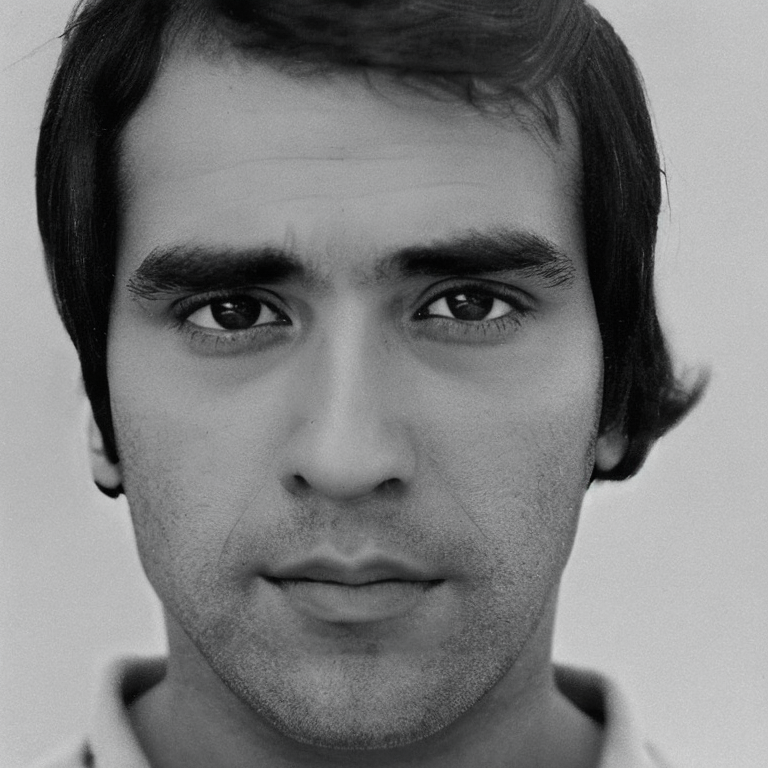

In [16]:
images = pipe_out.images
del pipe_out

for img in images:
    img.show()

In [30]:
from datasets import load_dataset

ds = load_dataset("lambdalabs/naruto-blip-captions", split="train")
ds

Repo card metadata block was not found. Setting CardData to empty.


Dataset({
    features: ['image', 'text'],
    num_rows: 1221
})

(1080, 1080)
a man with dark hair and brown eyes


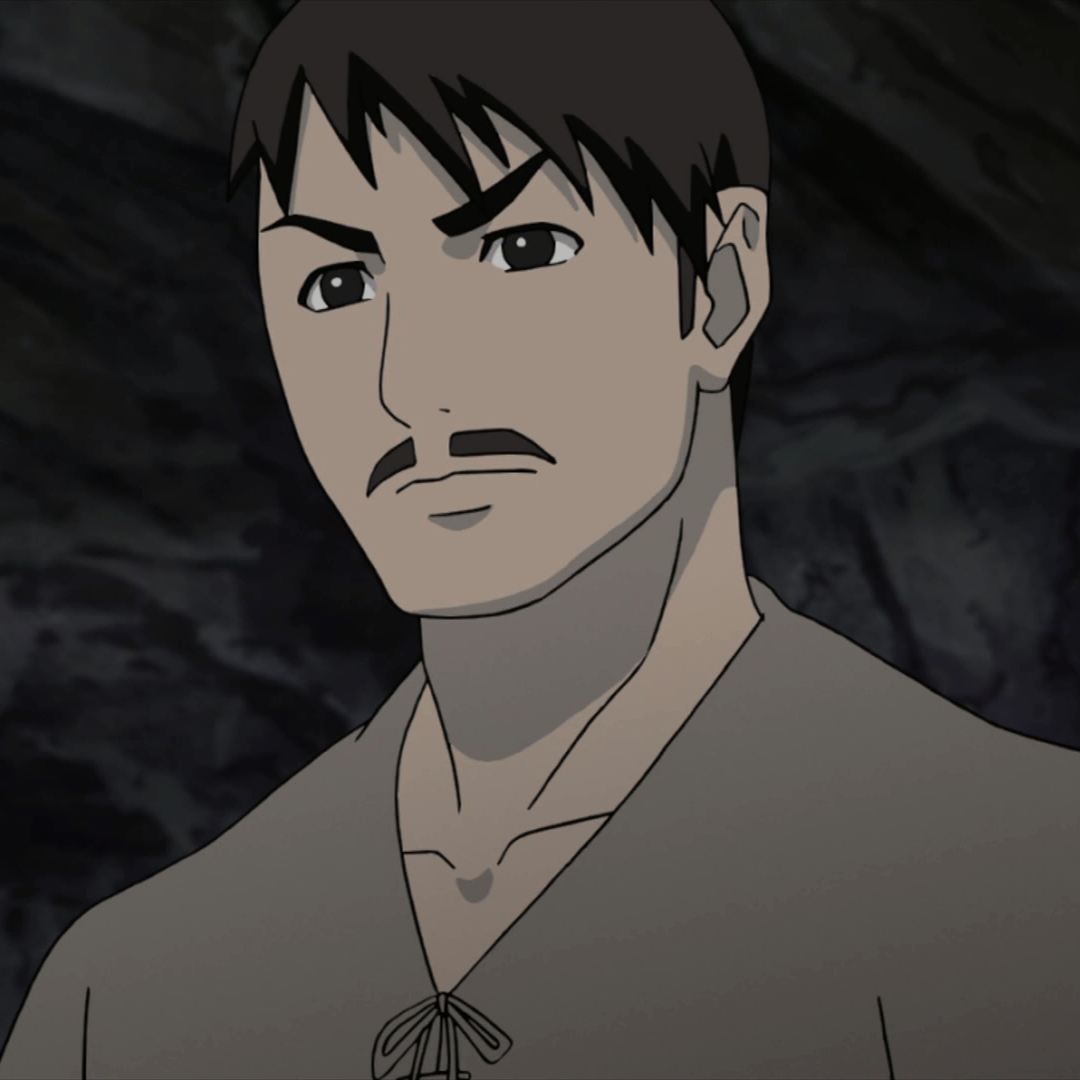

In [29]:
img = ds[0]["image"]
print(img.size)
print(ds[0]["text"])
img

In [31]:
import torchvision.transforms.v2 as transforms

image_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.ToImage(),  # PIL to tensor
    transforms.ToDtype(dtype=torch.get_default_dtype(), scale=True),  # convert PIL → tensor [0,1]
    transforms.Normalize([0.5], [0.5])  # map [0,1] → [-1,1]
])
image_transform(ds[:2]["image"])
ds.set_transform(image_transform)

## **Benchmarking data processing**

In [57]:
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm


class DummyDataset(Dataset):
    def __init__(self):
        self.ds = ds

    def __getitem__(self, index):
        return self.ds[index]

    def __len__(self):
        return len(self.ds)

In [56]:
for batch in tqdm(DataLoader(ds, batch_size=100, shuffle=True, num_workers=8)):
    batch = batch

100%|██████████| 13/13 [00:06<00:00,  1.87it/s]


In [58]:
for batch in tqdm(DataLoader(DummyDataset(), batch_size=100, shuffle=True, num_workers=8)):
    batch = batch

100%|██████████| 13/13 [00:06<00:00,  1.93it/s]


In [53]:
i_last = 0
for i in tqdm(range(0, len(ds), 100)):
    batch = ds[i:i + 100]
    i_last = i
batch = ds[i_last:]

100%|██████████| 13/13 [00:31<00:00,  2.40s/it]


In [12]:
tf_img = ds[10]["image"]
print(tf_img.shape, tf_img.min(), tf_img.max())
print(ds[0]["text"]
      )
print(ds.column_names)

torch.Size([3, 256, 256]) tensor(-0.9529) tensor(0.7255)
a man with dark hair and brown eyes
['image', 'text']


In [65]:
from torch.utils.data import DataLoader, default_collate

batch = [ds[i] for i in range(4)]
print(batch[0]["image"].shape, batch[0]["text"])
batch = default_collate(batch)
print(batch["image"].shape)
print(batch["text"])

input_ids = module.tokenizer(
    batch["text"],
    padding=True,
    return_tensors="pt"
).input_ids
print(input_ids.shape)

torch.Size([3, 256, 256]) a man with dark hair and brown eyes
torch.Size([4, 3, 256, 256])
['a man with dark hair and brown eyes', 'a man in a hoodie with a fire in the background', 'a man with a red hair and a black shirt', 'a man in a blue shirt and headband']
torch.Size([4, 13])


In [15]:
from torch.utils.data import DataLoader as TorchDataLoader, default_collate, Dataset
from lightning import LightningDataModule
from datasets import load_dataset, Dataset as ArrDataset
from typing import Callable, Iterable, TypeVar, Protocol, cast, Type, Generic, Iterator
from transformers import CLIPTokenizerFast, BatchEncoding
import torch
import torchvision.transforms.v2 as transforms


image_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.ToImage(),  # PIL to tensor
    transforms.ToDtype(dtype=torch.get_default_dtype(), scale=True),  # convert PIL → tensor [0,1]
    transforms.Normalize([0.5], [0.5])  # map [0,1] → [-1,1]
])

tokenizer: CLIPTokenizerFast = CLIPTokenizerFast.from_pretrained(model_id, subfolder="tokenizer")
def text_transform(text: str | list[str]) -> torch.Tensor:
    batch_encoding = tokenizer.__call__(
        text,
        padding=True,
        return_tensors="pt"
    )
    return batch_encoding.input_ids

_T_Co = TypeVar("_T_Co", covariant=True)
class DataLoader(TorchDataLoader, Generic[_T_Co]):
    def __iter__(self)->Iterator[_T_Co]:
        return cast(Iterator[_T_Co],super().__iter__())


_Batch_T = TypeVar("_Batch_T",bound=SDBatch, default = SDBatch, covariant=True)
class NarutoBlipDataModule(LightningDataModule, Generic[_Batch_T]):
    model_id = "lambdalabs/naruto-blip-captions"
    batch_type: Type[_Batch_T] = SDBatch

    def __init__(self,
                 image_transform_fn: Callable = None, text_transform_fn: Callable=None, num_workers: int=8, batch_size = 8):
        super().__init__()
        self.image_transform = image_transform_fn or image_transform
        self.text_transform = text_transform_fn or text_transform
        self.dataset: ArrDataset|None = None
        self.num_workers = num_workers
        self.batch_size = batch_size

    def _collate_fn(self, batch_l: list[dict])->_Batch_T:
        return self.batch_type.model_validate(default_collate(batch_l))

    def prepare_data(self) -> None:
        load_dataset(self.model_id)

    def setup(self, stage: str) -> None:
        dataset = load_dataset(self.model_id, split="train")
        def _transform(sample: dict):
            return dict(
                images=self.image_transform(sample["image"]),
                input_ids=self.text_transform(sample["text"])
            )
        dataset.set_transform(_transform)
        self.dataset = dataset

    def train_dataloader(self) -> DataLoader[_Batch_T]:
        return DataLoader(
            self.dataset,
            batch_size = self.batch_size,
            num_workers=self.num_workers,
            collate_fn=self._collate_fn
        )


In [22]:
data_module = NarutoBlipDataModule(batch_size=1)
data_module.setup("S")
dl = data_module.train_dataloader()
batch = next(iter(dl))

Repo card metadata block was not found. Setting CardData to empty.


In [23]:
print(batch.images.shape, batch.input_ids.shape) # good typed hint
print(batch.images.dtype, batch.input_ids.dtype)

torch.Size([1, 3, 256, 256]) torch.Size([1, 10])
torch.float32 torch.int64


In [19]:
from lightning import Trainer
data_module = NarutoBlipDataModule()

trainer = Trainer(fast_dev_run=True)
trainer.fit(module, datamodule=data_module)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/a3ilab01/h-ws/petorch/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless th

KeyError: "param 'initial_lr' is not specified in param_groups[0] when resuming an optimizer"